In [3]:
def searchsearial(list,number):
    for item in list:
        if item == number:
            return True
    return False

list1 = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
print(searchsearial(list1,8))

True


In [7]:
def search_by2(list,number,start,end):
    mid = (start+end)//2
    avg = list[mid]
    if start <=end:
        if avg > number:
             return search_by2(list,number,start,mid-1)
        elif avg < number:
            return search_by2(list,number,mid+1,end)
        else:
            return True
    return False

list1 = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]
print(search_by2(list1,16,0,len(list1)-1))

True


In [14]:
def sort(list1):
    for i in range(len(list1)-1,0,-1):
        for j in range(i):
            if list1[j] > list1[j+1]:
                temp = list1[j]
                list1[j] = list1[j+1]
                list1[j+1] = temp
    return list1

list1 = [1,9,6,9,2.5,5,82]
print(sort(list1))

[1, 2.5, 5, 6, 9, 9, 82]


In [25]:
def sort(list1):#从大从小排都没有影响
    for i in range(len(list1)-1,0,-1):
        max = 0
        for j in range(1,i+1):#选择排序从小到大排，如果是从大到小排应该是for j in range(i-1,-1)
            if list1[j] > list1[max]:
                max = j
        temp = list1[max]
        list1[max] = list1[i]
        list1[i] = temp

    return list1

list1 = [1,9,6,9,2.5,5,82]
print(sort(list1))

[1, 6, 9, 2.5, 9, 82, 5]


In [40]:
def sort_insert(lst):
    for i in range(1, len(lst)):
        temp = lst[i]  # 当前要插入的元素
        j = i - 1      # 从当前元素的前一个开始比较
        # 将比temp大的元素都向右移动一位
        while j >= 0 and temp < lst[j]:
            lst[j+1] = lst[j]
            j -= 1
        # 将temp插入到正确位置
        lst[j+1] = temp

    return lst

list1 = [1, 9, 6, 9, 2.5, 5, 82]
print(sort_insert(list1))

[1, 2.5, 5, 6, 9, 9, 82]


希尔排序算法

In [10]:
def shell_sort(list):
    sublistcount = len(list)//2
    while sublistcount > 0:
        for i in range(sublistcount):
            sort_insert_start(list,i,sublistcount)
        sublistcount = sublistcount//2
    return list

def sort_insert_start(lst,start_position,sublist_count):
    for i in range(start_position+sublist_count,len(lst),sublist_count):
        temp = lst[i]  # 当前要插入的元素
        j = i - sublist_count      # 从当前元素的前一个开始比较
        # 将比temp大的元素都向右移动一位
        while j >=start_position and temp < lst[j]:
            lst[j+sublist_count] = lst[j]
            j -= sublist_count
        # 将temp插入到正确位置
        lst[j+sublist_count] = temp
    return lst

list = [1, 9, 6, 9, 2.5, 5, 82]
print(shell_sort(list))

[1, 2.5, 5, 6, 9, 9, 82]


归并排序（类似于先序遍历）

In [13]:
def merge_sort(list):
    if len(list) <= 1:
        return list
    mid = len(list)//2
    left = merge_sort(list[:mid])
    right = merge_sort(list[mid:])
    list1 = []

    while left and right:
        if left[0] <= right[0]:
            list1.append(left.pop(0))
        else:
            list1.append(right.pop(0))

    list1.extend(left if left else right)
    return list1

list = [1, 9, 6, 9, 2.5, 5, 82]
print(merge_sort(list))

[1, 2.5, 5, 6, 9, 9, 82]


快速排序算法:自下而上地解决问题，在递归的过程中问题逐渐得到解决。（类似于后序遍历）

In [ ]:
def spiltportion(list,first,end):
    midpoint = list[first]
    left = first+1
    right = end
    done = False
    while not done:
        while left <= right and midpoint >= list[left]:
            left += 1
        while left <= right and midpoint <= list[right]:
            right -= 1
        if left > right :
            done = True
        else :
            temp = list[left]
            list[left] = list[right]
            list[right] = temp

    temp = list[first]
    list[first] = list[right]
    list[right] = temp
    return right

def sort_fast_helper(list,first,end):
    if first < end:
        mid = spiltportion(list,first,end)
        sort_fast_helper(list,first,mid-1)
        sort_fast_helper(list,mid+1,end)

def soft_fast(list):
    sort_fast_helper(list,0,len(list)-1)
    return list

list = [1, 9, 6, 9, 2.5, 5, 82]
print(soft_fast(list))

三路快速排序算法：

相较于普通的快速排序算法，能够处理含有重复值的情况



三路归并排序算法最开始会从数组中随机选取一个值，并将这个值与数组最左边的值互换，根据数组与该值(pivot)的大小关系将数组分为四个部分：

    1.[left+1,lt] : 小于pivot的部分，左闭右闭，最开始时区间为空，所以lt初始化为left

    2.[lt+1,i) : 等于pivot的部分，左闭右开，最开始时区间为空，i初始化为left+1

    3.[i,gt) : 待探索的区域

    4.[gt,right] : 大于pivot的部分，左闭右闭，最开始时区间为空，所以gt初始化为right+1

当划分完成以后，因为数组的首个元素属于等于区域，因此需要让其和小于区域的最后一个元素交换位置，既left与lt交换位置



In [1]:
from random import random

class Solution(object):
    def sortColors(self, nums):
        """
        :type nums: List[int]
        :rtype: None Do not return anything, modify nums in-place instead.
        """
        self.quicksort(nums,0,len(nums)-1)

    def partition(self,nums,left,right):

        pivoetIndex = random.randint(left,right)
        pivot = nums[pivoetIndex]
        nums[left],nums[pivoetIndex] = nums[pivoetIndex],nums[left]

        lt = left
        i = left + 1
        rt = right + 1

        while i < rt:#待探索区间为[i,gt)当二者相等时没有元素
            if nums[i] < pivot:#当前的值小于pivot时，小于区域要扩大，因此先进行lt+1的操作，因为之前lt+1的位置属于等于区域，因此需要让索引i与该位置的值进行交换，最后i+1，保证等于区域长度不变
                lt += 1
                nums[i],nums[lt] = nums[lt],nums[i]
                i += 1
            elif nums[i] == pivot:#当元素属于等于区域的时候，直接让i+1扩大等于区域的长度即可，
                i += 1
            else:#当属于大于区域的时候，先扩大大于区域的长度，在进行交换，注意此时不能直接进行i+1，因为从右边交换过来的值的大小未知
                rt -= 1
                nums[i],nums[rt] = nums[rt],nums[i]

        nums[left],nums[lt] = nums[lt],nums[left]

        return lt,rt

    def quicksort(self,nums,left,right):

        if left >= right:#基本结束条件不要忘，因为区间是左闭右闭型，因此这么写
            return

        lt,gt = self.partition(nums,left,right)

        self.quicksort(nums,left,lt-1)
        self.quicksort(nums,gt,right)

散列（哈希表）数据结构

完美散列函数
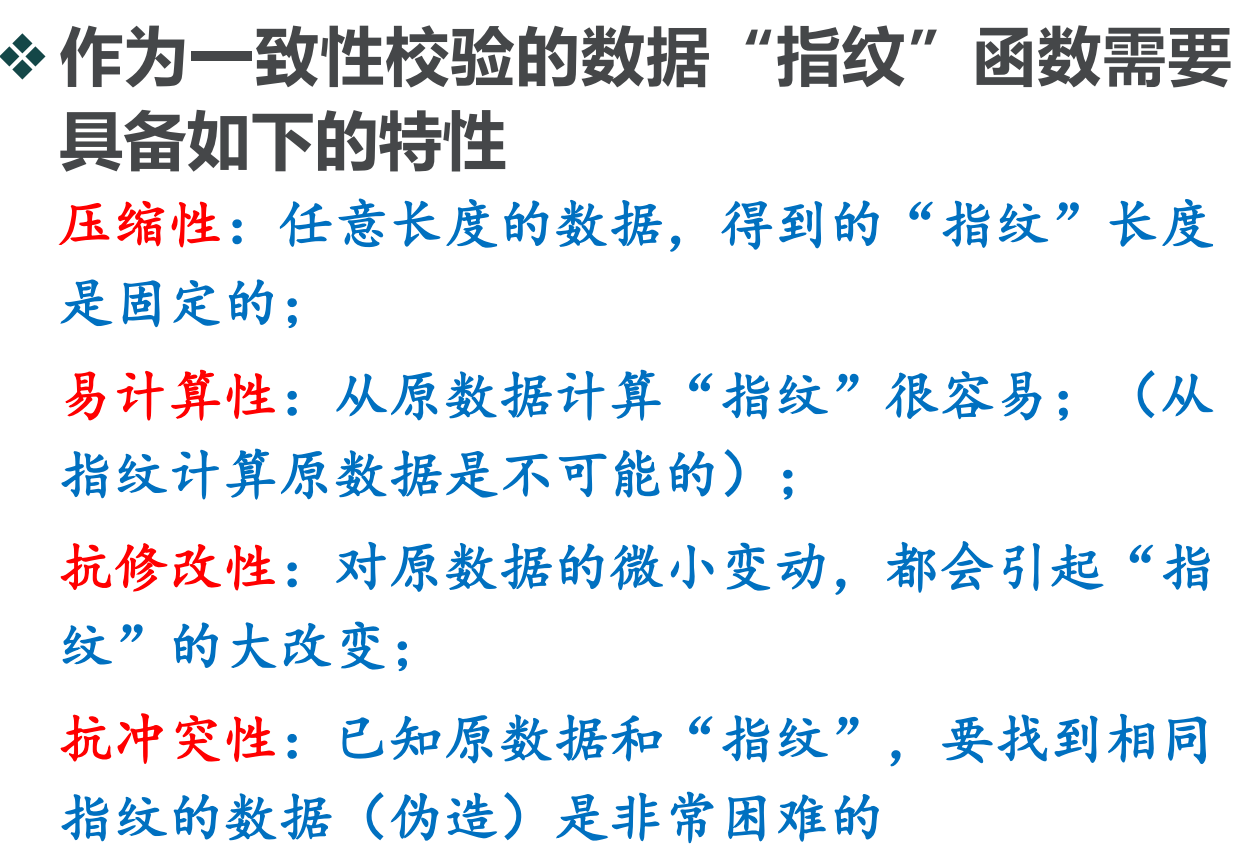

散列函数设计：

1.折叠法：

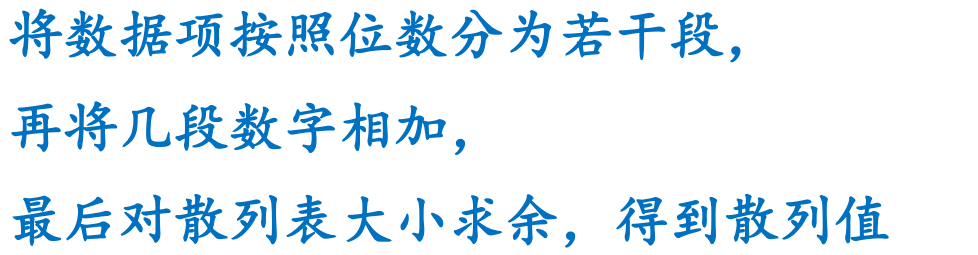

2.平方取中法：

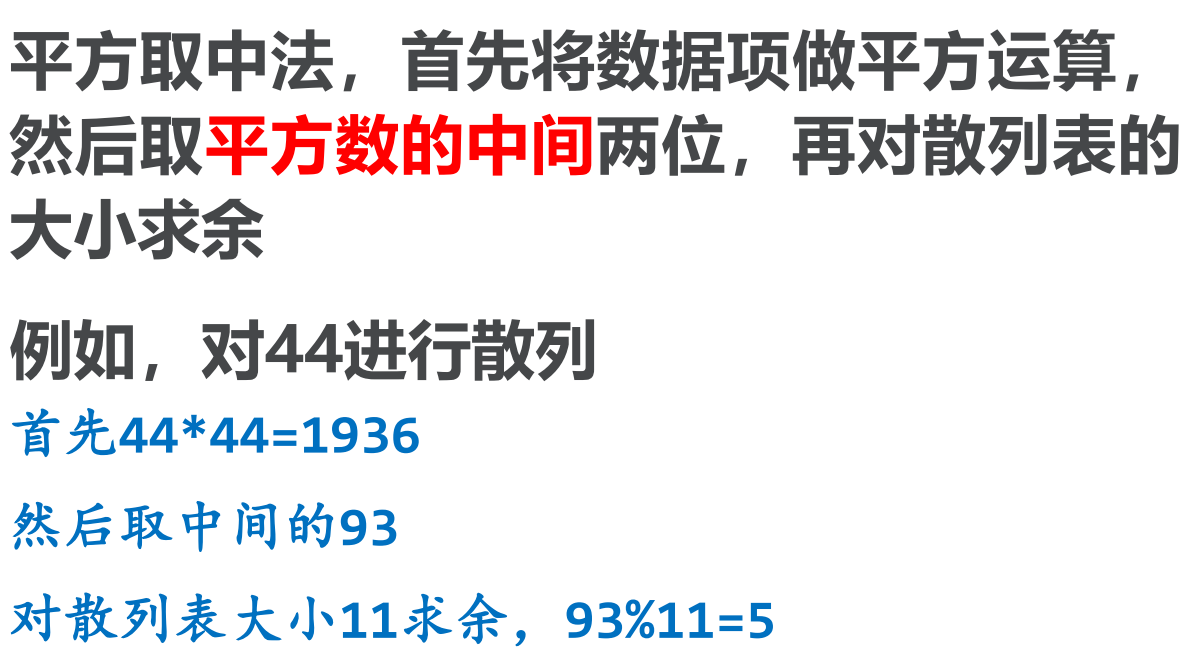

解决冲突：
1.线性探测

抽象数据类型“映射”

定义：

In [ ]:
class hashtable(object):
    def __init__(self, size):
        self.size = size
        self.key = [None] * size
        self.data = [None] * size

    def hash(self, key):
        return key % self.size

    def rehash(self, key):
        return (key+1) % self.size

def put_hash(key,data,hashtable):
    num = hashtable.hash(key)
    if hashtable.key[num] ==None:
        hashtable.key[num] = key
        hashtable.data[num] = data

    elif hashtable.key[num] == key:
        hashtable.data[num] = data

    else:
        stop = False
        startpoint = num
        num +=1
        while num != startpoint and not stop:
            if hashtable.key[num] == None:
                hashtable.key[num] = key
                hashtable.data[num] = data
                stop = True
            elif hashtable.key[num] == key:
                hashtable.data[num] = data
                stop = True
            else:
                num = hashtable.rehash(num)


In [ ]:
def search_hash(key, data, hashtable):
    num = hashtable.hash(key)
    start_point = num

    while True:
        if hashtable.key[num] is None:
            hashtable.key[num] = key
            hashtable.data[num] = data
            return True
        elif hashtable.key[num] == key:
            hashtable.data[num] = data
            return True

        num = hashtable.rehash(num)

        # 如果回到起点，说明表已满
        if num == start_point:
            return False